In [10]:
import pickle
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import r2_score
from vebir.metrics_utils import compute_compound_cors

import matplotlib.pyplot as plt

In [8]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon"

with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)
    
with open(PREPROC_DIR / "spectra_responses.pkl", "rb") as f:
    spectra_responses = pickle.load(f)

with open(GT_DIR / "ref_dict.pkl", "rb") as file:
    ref_dict = pickle.load(file)

CO2 = ref_dict["CO2"]
del ref_dict["CO2"]

H2O = np.array(pd.read_csv("../data/spectrabase/teflon/H2O_spectrum.csv"))
wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

ncomp_grid = 1 + np.arange(54)
tau_grid = 0.1 * np.power(2.0, np.arange(-2, 3))
a, b = np.meshgrid(ncomp_grid, tau_grid)
grid = np.column_stack([a.ravel(), b.ravel()])

In [9]:
with open(CORRECTIONS_DIR / "ebs_als_dict_W.pkl", "rb") as f:
    ebs_als_dict_W = pickle.load(f)

with open(CORRECTIONS_DIR / "ebs_pb_dict_W.pkl", "rb") as f:
    ebs_pb_dict_W = pickle.load(f)
    
with open(CORRECTIONS_DIR / "veb_pb_dict.pkl", "rb") as f:
    veb_pb_dict = pickle.load(f)

In [4]:
def predict_load(A,f):
    Fhat = []
    for istar in range(A.shape[0]):
        fhat = np.sum(A*A[istar,:],axis=1)/np.sum(A[istar,:]**2)*f[istar]
        fhat[istar] = np.nan
        Fhat.append(fhat)
    Fhat = np.array(Fhat)    
    fhat = np.nanmean(Fhat, axis=0)
    
    return fhat 

def compute_compound_r2_scores(compound_corrections, f):
    r2_dict = {}
    for param in compound_corrections:
        A = compound_corrections[param]
        fhat = predict_load(A,f)
        r2_dict[param] = r2_score(f, fhat)
    
    return r2_dict

In [ ]:
target_comp = "Ammonium sulfat"

In [13]:
if target_comp == "Ammonium sulfate":
    f = np.array(spectra_responses[target_comp]["AS"])
else:
    f = np.array(spectra_responses[target_comp]["OC"])

ref_profile = ref_dict[target_comp][:,1]
wn_gt = ref_dict[target_comp][:,0]

In [14]:
r2_dict = compute_compound_r2_scores(ebs_als_dict_W[target_comp], f)

max_cor = -1

for j in range(grid.shape[0]):
    corrections_dict = {}
    params = f"ncomp,tau = {int(grid[j, 0])},{grid[j, 1]}"
    for comp in ref_dict:
        corrections_dict[comp] = ebs_als_dict_W[comp][params]
    cors = compute_compound_cors(corrections_dict, ref_dict, wn)[target_comp]
    
    if np.mean(cors) > max_cor:
        max_cor = np.mean(cors)
        best_params = params
        corr_corrections = corrections_dict[target_comp]

In [17]:
thres = r2_dict[best_params]
valid_params = []
for params in r2_dict:
    if r2_dict[params] > thres:
        valid_params.append(params)
print(thres)

0.9740453532846163


['ncomp,tau = 7,0.025',
 'ncomp,tau = 8,0.025',
 'ncomp,tau = 9,0.025',
 'ncomp,tau = 10,0.025',
 'ncomp,tau = 11,0.025',
 'ncomp,tau = 12,0.025',
 'ncomp,tau = 13,0.025',
 'ncomp,tau = 14,0.025',
 'ncomp,tau = 15,0.025',
 'ncomp,tau = 16,0.025',
 'ncomp,tau = 17,0.025',
 'ncomp,tau = 18,0.025',
 'ncomp,tau = 19,0.025',
 'ncomp,tau = 20,0.025',
 'ncomp,tau = 21,0.025',
 'ncomp,tau = 22,0.025',
 'ncomp,tau = 23,0.025',
 'ncomp,tau = 24,0.025',
 'ncomp,tau = 25,0.025',
 'ncomp,tau = 26,0.025',
 'ncomp,tau = 27,0.025',
 'ncomp,tau = 28,0.025',
 'ncomp,tau = 29,0.025',
 'ncomp,tau = 30,0.025',
 'ncomp,tau = 31,0.025',
 'ncomp,tau = 32,0.025',
 'ncomp,tau = 33,0.025',
 'ncomp,tau = 34,0.025',
 'ncomp,tau = 35,0.025',
 'ncomp,tau = 36,0.025',
 'ncomp,tau = 37,0.025',
 'ncomp,tau = 38,0.025',
 'ncomp,tau = 39,0.025',
 'ncomp,tau = 40,0.025',
 'ncomp,tau = 41,0.025',
 'ncomp,tau = 42,0.025',
 'ncomp,tau = 43,0.025',
 'ncomp,tau = 44,0.025',
 'ncomp,tau = 45,0.025',
 'ncomp,tau = 46,0.025',
 'n

In [545]:
print(valid_params[-2],r2_dict[valid_params[-2]])

ncomp,tau = 53,0.4 0.9823572871251195


In [546]:
r2_corrections = ebs_als_dict_W[target_comp][valid_params[-2]]
r2_profile =r2_corrections.T@f / np.sum(f**2)
corr_profile = (corr_corrections.T @ f) / np.sum(f**2)

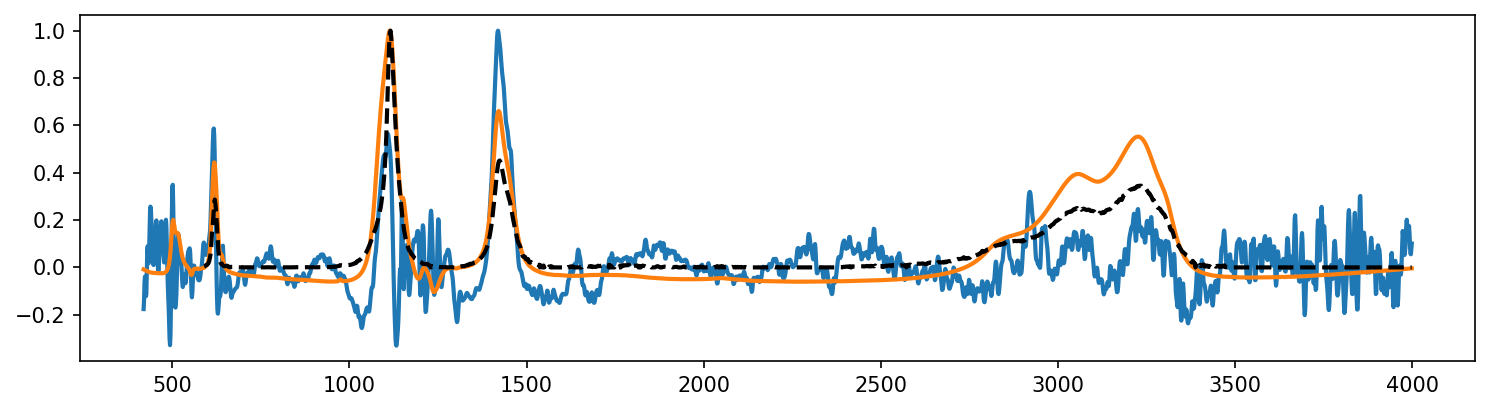

In [547]:
plt.figure(figsize=(12, 3), dpi=150)
plt.plot(wn,r2_profile/np.max(r2_profile),linewidth=2)
plt.plot(wn,corr_profile/np.max(corr_profile),linewidth=2)
plt.plot(
    wn_gt,
    ref_profile / np.max(ref_profile),
    'k--',
    label='reference',
    linewidth=2  # or lw=2
)

In [14]:
veb_pb_dict

{'1-Docosanol': {0: {'MAP': array([ 2.63605110e-03,  2.39243412e-03,  1.88740613e-03, ...,
           3.76466198e-05,  4.80889609e-06, -2.68425608e-05], shape=(2785,)),
   'tau': np.float64(0.03023000736897452),
   'sigma_hat': np.float64(3.445209829092228e-05),
   'nu': array([ 0.13551791, -3.97082361, -2.29733203, -0.057866  ,  1.80352401,
           1.15336694,  5.93540347, -5.3038589 ,  5.1325796 , -2.70924025,
          -4.5583567 ,  3.52284504, -2.05303415,  1.79568749, -3.00779502,
          -5.78791833, -6.55356054, -7.7729888 ,  2.74015011, -1.04439645,
          -3.27393833, -4.62789811,  7.30044242,  1.90537469,  6.17731217,
           3.29473646, -2.20920705, -0.30552099,  0.49210685, -1.50584212,
          -0.59783111, -2.01076574, -1.30221348,  1.01384456,  0.32563993,
          -1.44253592, -0.15897205,  0.57698088,  0.12701847, -0.12972147,
           0.26937294, -0.41941742,  0.1252385 , -0.45902569, -0.11109996,
          -0.0259776 ,  0.15164067]),
   'd': array([7.1

In [150]:
f = []
A = []

for comp in spectra_responses:
    if comp == "Ammonium sulfate":
        continue
    else:
        f.append(np.array(spectra_responses[comp]["OC"]))
        
        Anew = []

        for i in veb_pb_dict[comp]:
            Anew.append(veb_pb_dict[comp][i]["MAP"])

        Anew = np.array(Anew)
        A.append(Anew)
        
f = np.concatenate(f)
A = np.concatenate(A,axis=0)

In [140]:
f = []
A = []

best_params = "ncomp,tau = 12,0.025"

for comp in spectra_responses:
    if comp == "Ammonium sulfate":
        continue
    else:
        f.append(np.array(spectra_responses[comp]["OC"]))
        A.append(ebs_als_dict_W[comp][best_params])
        
f = np.concatenate(f)
A = np.concatenate(A,axis=0)

In [141]:
from sklearn.cross_decomposition import PLSRegression as PLS
from sklearn.metrics import mean_absolute_percentage_error as mape

In [142]:
def loocv_pls(A,f,max_ncomp=50):
    cv_preds = np.zeros([f.shape[0],max_ncomp])
    
    for c in tqdm(range(1,max_ncomp+1)):
        mod = PLS(n_components=c)
        for i in range(f.shape[0]):
            mod.fit(np.delete(A,i,axis=0),np.delete(f,i))
            cv_preds[i,c-1] = mod.predict(A[[i],:])[0]
        
    return cv_preds

In [151]:
cv_preds = loocv_pls(A,f,max_ncomp=20)

100%|██████████| 20/20 [01:23<00:00,  4.17s/it]


In [152]:
np.argmin([mape(f,cv_preds[:,i]) for i in range(cv_preds.shape[1])])

np.int64(17)

In [161]:
thres = np.sort(f)[18]
idx = f <= thres

In [162]:
[r2_score(f[idx],cv_preds[idx,i]) for i in range(cv_preds.shape[1])][17]

0.31532013689978433

In [149]:
[r2_score(f[idx],cv_preds[idx,i]) for i in range(cv_preds.shape[1])][16]

0.2862239863018302

In [80]:
np.max([r2_score(f,cv_preds[:,i]) for i in range(cv_preds.shape[1])])

np.float64(0.9986296479165884)

In [81]:
np.argmax([r2_score(f,cv_preds[:,i]) for i in range(cv_preds.shape[1])])

np.int64(10)

In [97]:
[r2_score(f[idx],cv_preds[idx,i]) for i in range(cv_preds.shape[1])][10]

0.8760531174418268

In [ ]:
ncomp,tau = 53,0.4

array([ 4.04404245, 11.4400805 ,  5.00395956,  7.66498415,  4.63032087,
        5.75896764,  3.32916856,  3.29188035,  3.57989554,  3.55936887])

In [89]:
f[idx]

array([1.42125015, 0.76038412, 1.01979674, 0.98084333, 0.68659033,
       0.98084333, 1.37318066, 1.27509633, 0.68659033, 1.27509633,
       0.88275899, 1.27509633, 1.36199226, 0.47737308, 0.30635811,
       0.47002888, 0.59592947, 1.36811978, 1.22543244, 1.22123575])

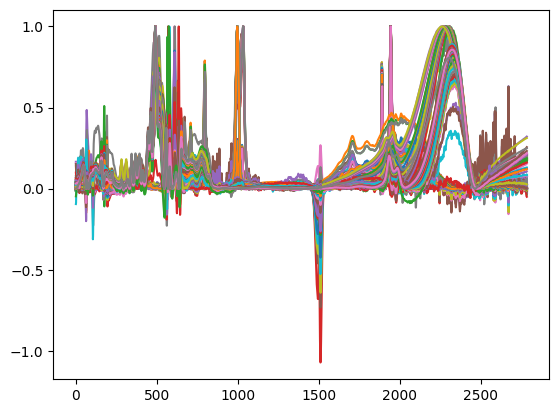

In [114]:
for i in range(A.shape[0]):
    plt.plot(A[i,:]/np.max(A[i,:]))